# Mask Generation for LISS-4 Satellite Images

#### Team - Shaan

Members:

Shri Suman Senapati

Smt. Neha Senapati

# Libraries

In [4]:
import os
import gc
import numpy as np
import pandas as pd
import torch
import rasterio
from rasterio.windows import Window
import cv2
from tqdm import tqdm
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import geopandas
from shapely.geometry import shape
from datetime import datetime
import warnings
import matplotlib.pyplot as plt

In [5]:
warnings.filterwarnings('ignore')

# Helper Functions

In [7]:
## Function to Parse Metadata from individual scenes. Format needs to be same as that shared during Training
def parse_metadata_for_scene(scene_path):
    metadata_filepath = os.path.join(scene_path, 'Band_meta.txt')
    if not os.path.exists(metadata_filepath): return None
    meta_dict = {}
    with open(metadata_filepath, 'r') as f:
        for line in f:
            if '=' in line:
                key, value = line.split('=', 1)
                meta_dict[key.strip()] = value.strip()
    try:
## Extract and map the Satellite ID
        sat_id_raw = meta_dict['SatID']
        if 'R2A' in sat_id_raw:
            satellite_category = 'RS2A'
        elif 'R2' in sat_id_raw:
            satellite_category = 'RS2'
        else:

## Fallback if the satellite ID is unknown
            print(f"Warning: Unknown satellite ID '{sat_id_raw}'. ESUN lookup may fail.")
            satellite_category = None

        sun_elevation = float(meta_dict['SunElevationAtCenter'])
        pass_date_obj = datetime.strptime(meta_dict['DateOfPass'], '%d-%b-%Y')
        julian_day = pass_date_obj.timetuple().tm_yday
        bits_per_pixel = float(meta_dict['BitsPerPixel'])
        max_dn = (2**bits_per_pixel) - 1
        
        final_metadata = {
            'satellite_category': satellite_category # Store the determined category
        }
        for band_num in [2, 3, 4]:
            lmax, lmin = float(meta_dict[f'B{band_num}_Lmax']), float(meta_dict[f'B{band_num}_Lmin'])
            gain = (lmax - lmin) / max_dn
            offset = lmin
            final_metadata[f'band{band_num}'] = {'julian_day': julian_day, 'gain': gain, 'offset': offset, 'sun_elevation_angle_deg': sun_elevation}
        return final_metadata
    except (KeyError, ValueError) as e: return None


## Function to calculate reflectance from Digital Numbers
def dn_to_toa_reflectance_accurate(band_array, band_num, julian_day, gain, offset, sun_elevation_angle_deg, satellite_category):
    if d_values_df is None or liss_esun_df is None: return None
    try:
        d = d_values_df.loc[d_values_df['DOY'] == julian_day, 'd'].values[0]
        
 ## ESUN lookup now filters by satellite category
        band_str = f'B{band_num}'
        esun = liss_esun_df.loc[
            (liss_esun_df['B'] == band_str) & (liss_esun_df['Cat'] == satellite_category),
            'LISS4'
        ].values[0]
        
        radiance = gain * band_array.astype(np.float64) + offset
        numerator = np.pi * radiance * (d**2)
        denominator = esun * np.sin(np.deg2rad(sun_elevation_angle_deg))
        return numerator / denominator
    except IndexError:
        print(f"Error: Could not find ESUN value for Sat: '{satellite_category}', Band: '{band_str}'")
        return None


## Function to generate the GIS outputs, with edge processing and visualization
def generate_gis_outputs(scene_path, unet_model, output_dir="gis_outputs"):
    print(f"\nProcessing Scene: {os.path.basename(scene_path)}")
    os.makedirs(output_dir, exist_ok=True)
    current_metadata = parse_metadata_for_scene(scene_path)
    if not current_metadata:
        print(f"Skipping scene due to metadata error.")
        return

    with rasterio.open(os.path.join(scene_path, 'BAND4.tif')) as src:
        h, w, original_crs, original_transform = src.height, src.width, src.crs, src.transform

    # --- Perform Radiometric Correction ---
    satellite_category = current_metadata['satellite_category']
    refl_b2 = dn_to_toa_reflectance_accurate(rasterio.open(os.path.join(scene_path, 'BAND2.tif')).read(1), 2, satellite_category=satellite_category, **current_metadata['band2'])
    refl_b3 = dn_to_toa_reflectance_accurate(rasterio.open(os.path.join(scene_path, 'BAND3.tif')).read(1), 3, satellite_category=satellite_category, **current_metadata['band3'])
    refl_b4 = dn_to_toa_reflectance_accurate(rasterio.open(os.path.join(scene_path, 'BAND4.tif')).read(1), 4, satellite_category=satellite_category, **current_metadata['band4'])

    if refl_b2 is None or refl_b3 is None or refl_b4 is None:
        print(f"Skipping scene {os.path.basename(scene_path)} due to reflectance calculation error.")
        return

    refl_full = np.stack([refl_b4, refl_b3, refl_b2], axis=-1)
    v_min, v_max = np.percentile(refl_full, (2, 98))
    rgb_8bit_full = (np.clip((refl_full - v_min) / (v_max - v_min + 1e-8), 0, 1) * 255).astype(np.uint8)

    # --- Run Sliding Window Inference with Padding ---
    predicted_mask = np.zeros((h, w), dtype=np.uint8)
    unet_model.eval()
    inference_transform = A.Compose([A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()])
    
    for i in tqdm(range(0, h, 512), desc="Inferring", leave=False):
        for j in range(0, w, 512):
            chip = rgb_8bit_full[i:i+512, j:j+512]
            original_h, original_w, _ = chip.shape

            # Pad edge chips to make them 512x512
            if original_h < 512 or original_w < 512:
                pad_h = 512 - original_h
                pad_w = 512 - original_w
                chip = cv2.copyMakeBorder(chip, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=[0, 0, 0])
            
            transformed_chip = inference_transform(image=chip)['image']
            with torch.no_grad():
                pred_logits = unet_model(transformed_chip.unsqueeze(0).to(DEVICE))
                pred_chip_mask = torch.argmax(pred_logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

            # Crop the prediction back to the original chip size before placing
            cropped_prediction = pred_chip_mask[:original_h, :original_w]
            predicted_mask[i:i+original_h, j:j+original_w] = cropped_prediction

    # --- Save GIS Outputs ---
    scene_name = os.path.basename(scene_path)
    geotiff_path = os.path.join(output_dir, f"{scene_name}_mask.tif")
    with rasterio.open(geotiff_path, 'w', driver='GTiff', height=h, width=w, count=1, dtype=rasterio.uint8, crs=original_crs, transform=original_transform) as dst:
        dst.write(predicted_mask, 1)
    print(f"  -> Saved GeoTIFF mask to {geotiff_path}")

    # --- Visualize Final Result ---
    print("  -> Generating visual overlay...")
    downscale_factor = 10
    display_width = w // downscale_factor
    display_height = h // downscale_factor
    
    rgb_display = cv2.resize(rgb_8bit_full, (display_width, display_height), interpolation=cv2.INTER_AREA)

    mask_color = np.zeros((h, w, 4), dtype=np.uint8)
    mask_color[predicted_mask == 1] = [0, 255, 0, 150]  # Green for Clouds
    mask_color[predicted_mask == 2] = [0, 0, 255, 150]  # Black for Shadows
    
    mask_display = cv2.resize(mask_color, (display_width, display_height), interpolation=cv2.INTER_NEAREST)

    rgb_display_rgba = cv2.cvtColor(rgb_display, cv2.COLOR_RGB2RGBA)
    alpha = mask_display[:, :, 3] / 255.0
    overlay = np.copy(rgb_display_rgba)
    for c in range(0, 3):
        overlay[:, :, c] = (1.0 - alpha) * rgb_display_rgba[:, :, c] + alpha * mask_display[:, :, c]

    fig, ax = plt.subplots(1, 2, figsize=(20, 10))
    fig.suptitle(f'Inference Result for {scene_name}', fontsize=16)
    ax[0].imshow(rgb_display)
    ax[0].set_title('Original Scene (Downscaled)')
    ax[0].axis('off')
    ax[1].imshow(overlay)
    ax[1].set_title('Scene with Cloud (Green) & Shadow (Blue) Overlay')
    ax[1].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Generation Script

Using device: cpu
Calibration files loaded successfully.
Loading model weights from unet_resnet50_best_3.pth...
Model loaded successfully.
Found 3 scenes to process.

Processing Scene: R2F10JUN2025073387009300046SSANSTUC00GTDC_subset1


  -> Saved GeoTIFF mask to gis_outputs\R2F10JUN2025073387009300046SSANSTUC00GTDC_subset1_mask.tif
  -> Generating visual overlay...


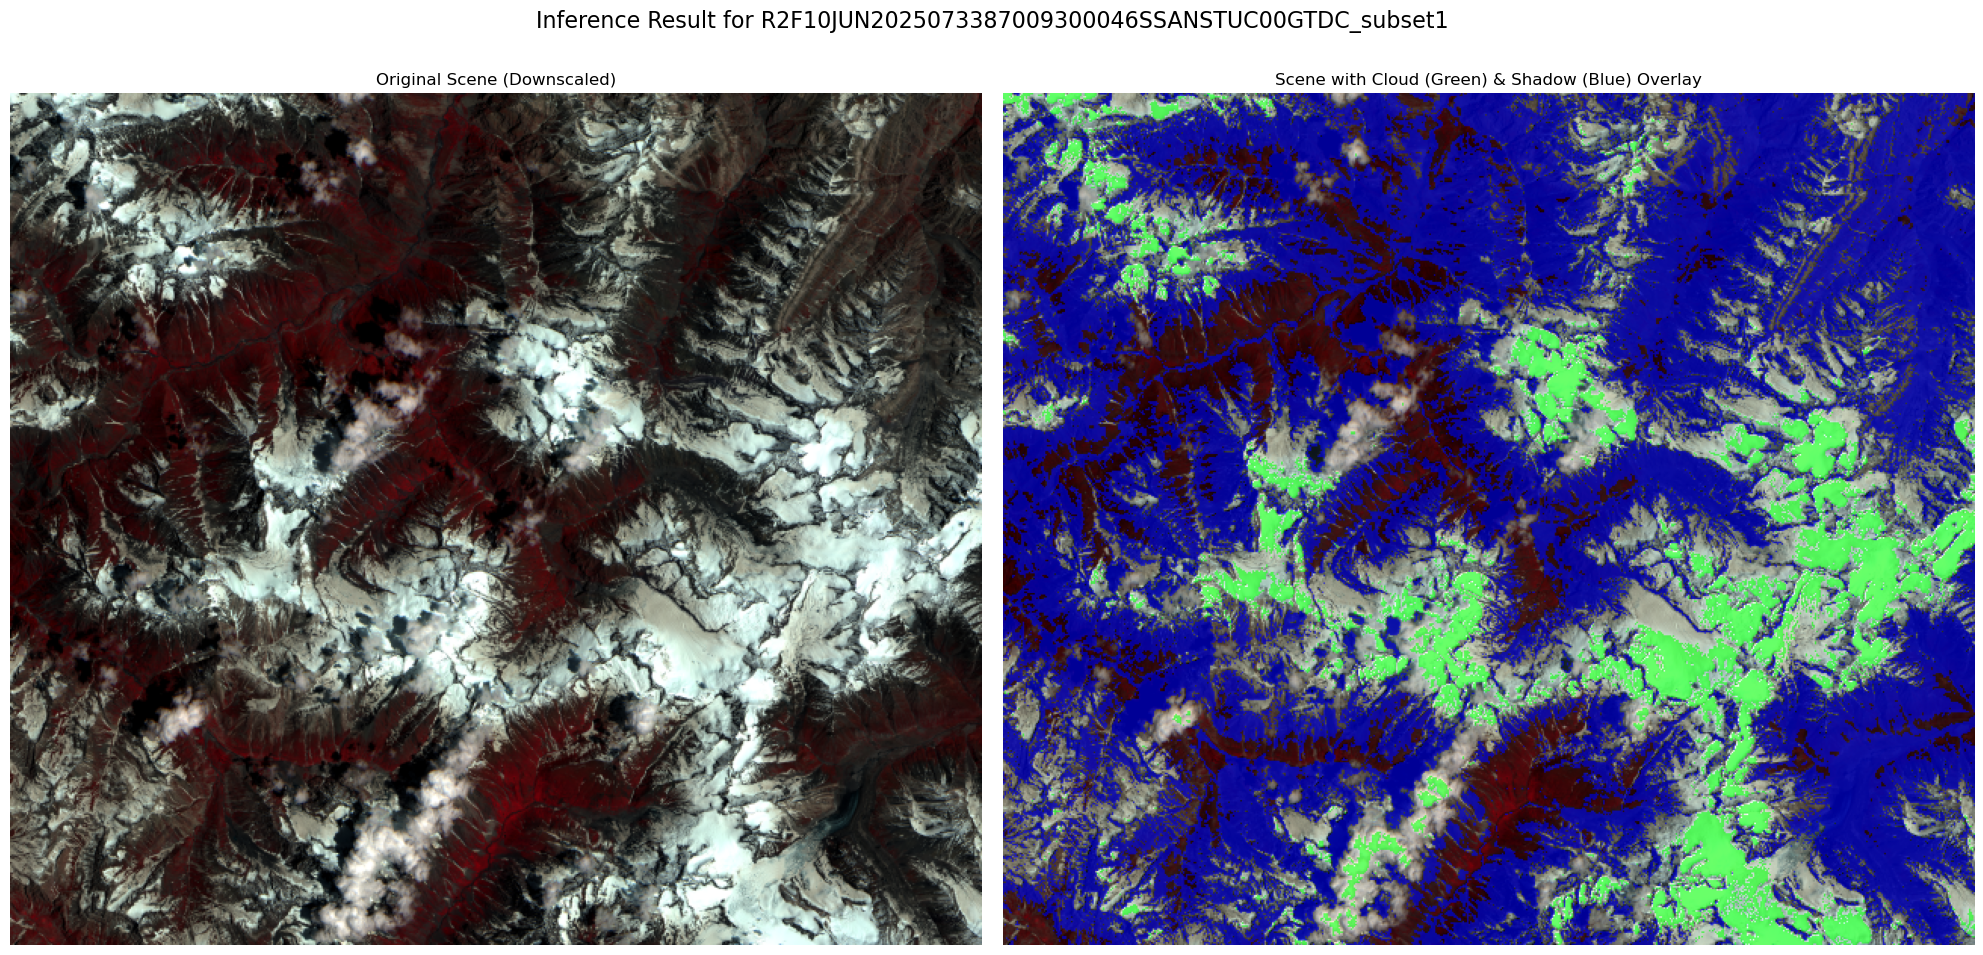


Processing Scene: R2F30OCT2024070225010600057SSANSTUC00GTDB_subset2


  -> Saved GeoTIFF mask to gis_outputs\R2F30OCT2024070225010600057SSANSTUC00GTDB_subset2_mask.tif
  -> Generating visual overlay...


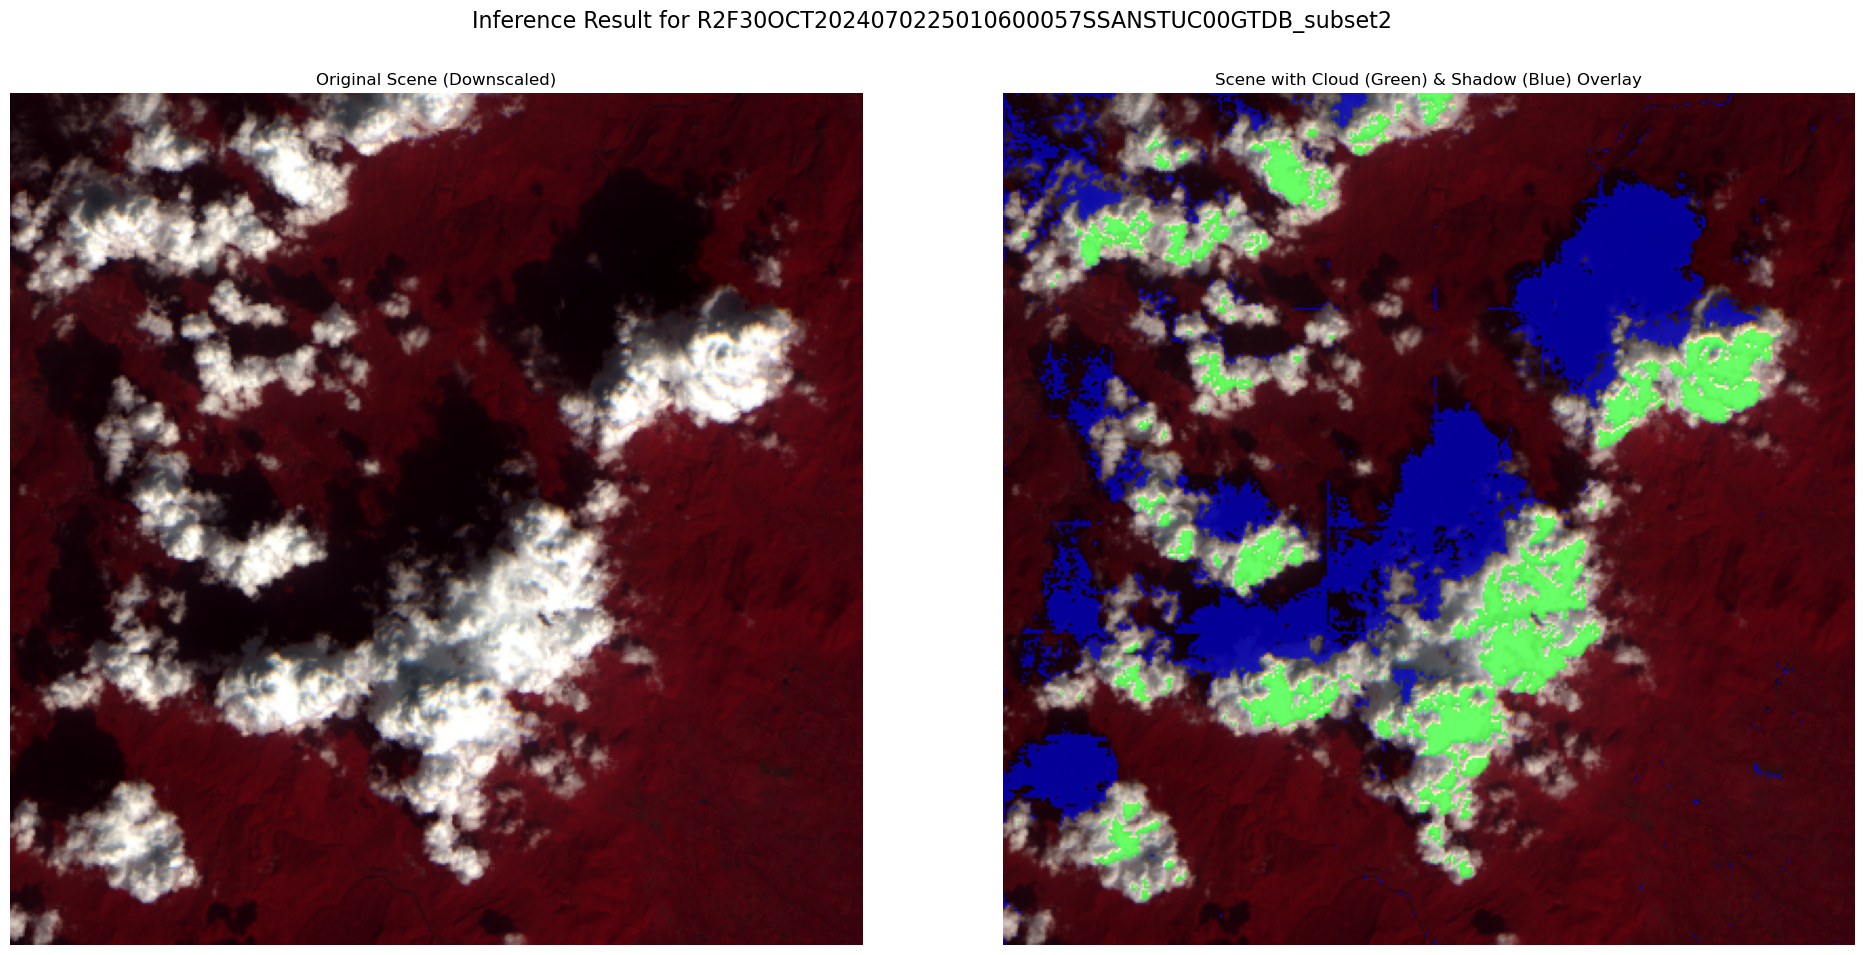


Processing Scene: RAF01NOV2020020248009600062SSANSTUC00GTDB_subset2


  -> Saved GeoTIFF mask to gis_outputs\RAF01NOV2020020248009600062SSANSTUC00GTDB_subset2_mask.tif
  -> Generating visual overlay...


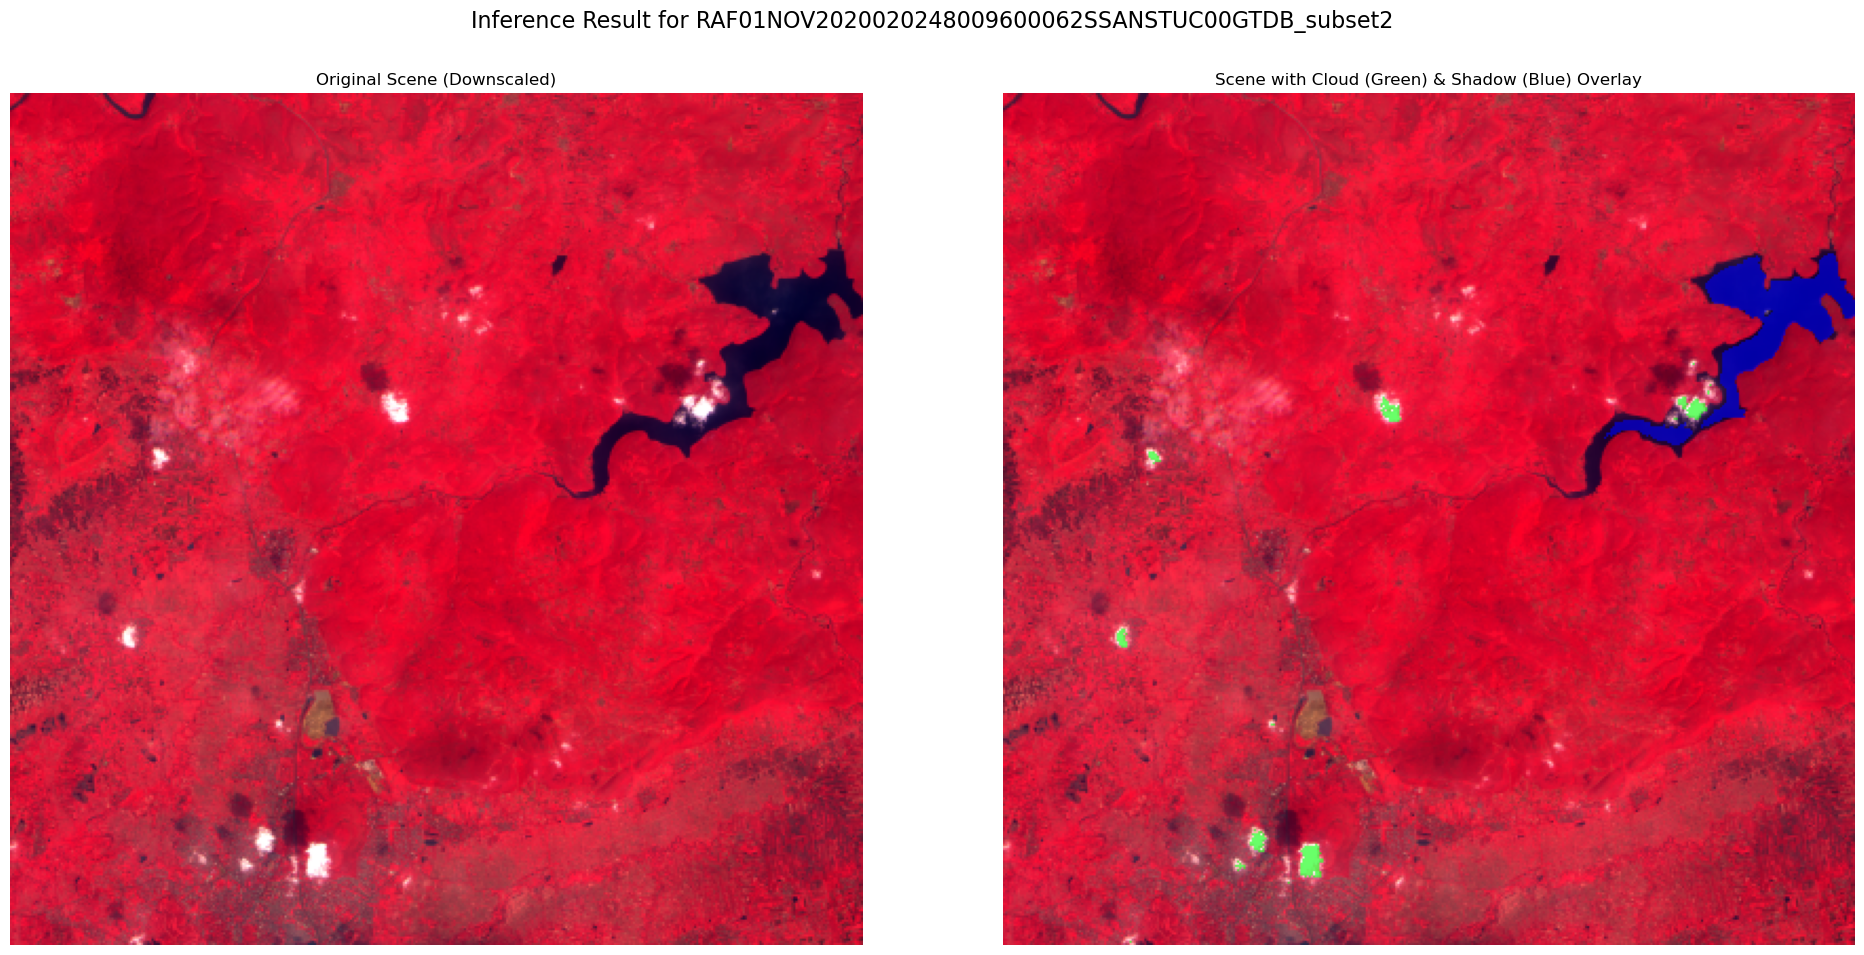

Inference complete for all test scenes.


In [14]:
if __name__ == "__main__":
    
## Configuration for functions
    MODEL_WEIGHTS_PATH = "unet_resnet50_best_3.pth"
    BEST_MODEL_BACKBONE = "resnet50"
    TEST_SET_PARENT_DIR = "evalset"  # This should be the top-level folder containing all  test scenes
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"Using device: {DEVICE}")

## Loading Calibration Data. The calibration data shared for day-wise values of d, and ESun for LISS-4 are loaded into two separate csv files for easier handling
    try:
        d_values_df = pd.read_csv('d_values.csv')
        liss_esun_df = pd.read_csv('LISS.csv')
        print("Calibration files loaded successfully.")
    except FileNotFoundError:
        print("Error: 'd_values.csv' and 'LISS.csv' must be in the same folder as this script.")
        exit()

# Loading backbone model weights
    try:
        print(f"Loading model weights from {MODEL_WEIGHTS_PATH}...")
        model = smp.Unet(BEST_MODEL_BACKBONE, in_channels=3, classes=3).to(DEVICE)
        model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=torch.device(DEVICE)))
        print("Model loaded successfully.")
    except FileNotFoundError:
        print(f"Error: Model weights file not found at '{MODEL_WEIGHTS_PATH}'")
        exit()

 # Running inference
    if not os.path.isdir(TEST_SET_PARENT_DIR):
        print(f"Error: The provided test set directory is not valid: '{TEST_SET_PARENT_DIR}'")
    else:
        test_scene_paths = []
        for scene_id in os.listdir(TEST_SET_PARENT_DIR):
            outer_path = os.path.join(TEST_SET_PARENT_DIR, scene_id)
            if os.path.isdir(outer_path):
                inner_path = os.path.join(outer_path, scene_id)
                if os.path.isdir(inner_path):
                    test_scene_paths.append(inner_path)
        
        if not test_scene_paths:
            print(f"No valid scenes with nested folders found in '{TEST_SET_PARENT_DIR}'.")
        else:
            print(f"Found {len(test_scene_paths)} scenes to process.")
            
            for scene_path in test_scene_paths:
                generate_gis_outputs(scene_path, model)
            
            print("Inference complete for all test scenes.")